In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Julia set for z_{n+1} = z_n^2 + c with fixed c
X = np.linspace(-2.0, 2.0, 1000)
Y = np.linspace(-2.0, 2.0, 1000)
c = -0.744 + 0.148j
z_tol = 2
max_iter = 50

X_grid, Y_grid = np.meshgrid(X, Y)
Z_grid = X_grid + Y_grid * 1j


def julia_sequence(z0_grid, num_iters):
    """
    Vectorized Julia iteration: z_{n+1} = z_n^2 + c with fixed c.
    Returns the final z values (used for coloring by magnitude).
    """
    z = z0_grid.copy()
    for _ in range(num_iters):
        mask = np.abs(z) <= z_tol
        z = np.where(mask, z * z + c, z)
    return z

In [3]:
Z_hit = np.abs(julia_sequence(Z_grid, max_iter))
Z_hit = np.minimum(Z_hit, z_tol)  # cap escaped points for consistent coloring

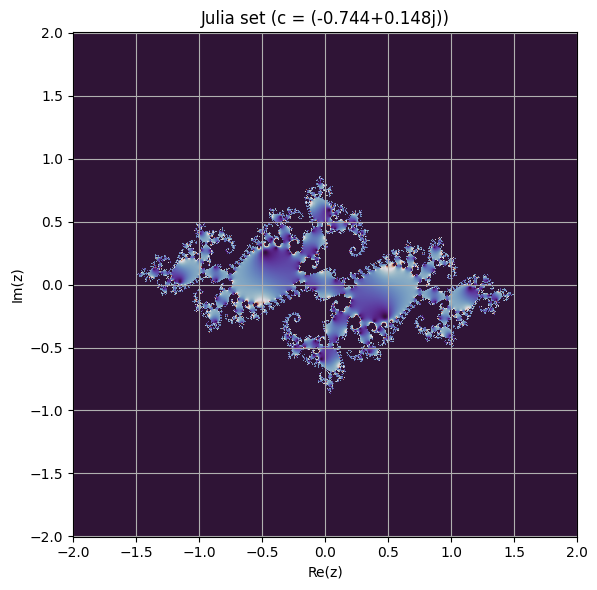

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.pcolormesh(X_grid, Y_grid, Z_hit, cmap="twilight_shifted")
ax.set_xlabel("Re(z)")
ax.set_ylabel("Im(z)")
ax.set_title(f"Julia set (c = {c})")
ax.grid(True)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()